# Spinu (2013) Risk Parity via SOCP + DPP — A CVXPY Tutorial

*A hands-on walkthrough of equal-risk-contribution (ERC) portfolios via
Spinu's convex reformulation, with DPP caching for fast walk-forward use.*

This notebook is a companion to
[`portfolio_optimization_dpp.ipynb`](./portfolio_optimization_dpp.ipynb)
(mean-variance). The two live at different points on CVXPY's cone
hierarchy: MV is a pure SOC problem, while ERC via Spinu introduces a
negative-log barrier that puts the canonicalized problem in the
**exponential cone**. Every lesson here is therefore also about which
solvers can handle which cones — a gotcha that bites people porting
quadratic code to risk parity.

**Three things you will learn:**

1. Why the natural ERC condition $w_i \cdot (\Sigma w)_i = \text{const}$
   is non-convex in $w$, and how Spinu's change of variables turns it into
   a strictly convex program with a unique global optimum.

2. How to DPP-cache the resulting problem. The Cholesky trick from the
   MV tutorial extends cleanly: `0.5 * sum_squares(L.T @ y)` is DPP-compliant
   and matches `0.5 * y.T @ Sigma @ y` exactly.

3. The same `quad_form(y, Sigma_param)` non-DPP gotcha that bit us in the
   MV tutorial bites again here, and we also have to watch for a sign-
   attribute requirement on the budget Parameter specific to the log barrier.

Plus:

- Numerical stability on ill-conditioned / near-rank-deficient Σ
- Walk-forward backtest: ERC vs equal-weight on real price data
- Solver compatibility: OSQP (no EXP cone) fails, CLARABEL succeeds


## 0. Setup

In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

print(f"cvxpy {cp.__version__}  |  numpy {np.__version__}  |  pandas {pd.__version__}")


cvxpy 1.8.2  |  numpy 2.4.3  |  pandas 2.3.3


## 1. Data pipeline

[yfinance](https://github.com/ranaroussi/yfinance) knows
how to fetch and align historical close prices, handle yfinance's
`MultiIndex` quirks, and return a clean DataFrame. We reuse its data layer
so the tutorial is a realistic end-to-end workflow rather than a toy
synthetic benchmark.

If `yfinance` is unavailable (no network, etc.), we fall back to geometric
Brownian motion with a fixed seed so this notebook always runs end-to-end.


In [2]:
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "BRK-B", "JPM", "JNJ",
    "V", "PG", "UNH", "HD", "MA",
    "DIS", "BAC", "XOM", "PFE", "KO",
]


def load_prices(tickers, period="2y"):
    try:
        import yfinance as yf

        data = yf.download(
            tickers, period=period, progress=False, auto_adjust=True,
        )
        if isinstance(data.columns, pd.MultiIndex):
            prices = data["Close"]
        else:
            prices = data[["Close"]]
            prices.columns = tickers[:1]
        prices = prices.dropna(axis=1, how="any")
        if not prices.empty and len(prices) > 260:
            return prices
    except Exception as exc:
        print(f"[warn] yfinance fetch failed ({exc}); using synthetic data")
    rng = np.random.default_rng(42)
    n_days = 504
    drift = rng.uniform(0.05, 0.15, size=len(tickers)) / 252
    vol = rng.uniform(0.15, 0.40, size=len(tickers)) / np.sqrt(252)
    shocks = rng.standard_normal((n_days, len(tickers))) * vol + drift
    prices_arr = 100.0 * np.exp(np.cumsum(shocks, axis=0))
    idx = pd.date_range(end=pd.Timestamp.today(), periods=n_days, freq="B")
    return pd.DataFrame(prices_arr, index=idx, columns=tickers)


prices = load_prices(TICKERS, period="2y")
print(f"Loaded {prices.shape[0]} trading days for {prices.shape[1]} tickers")
prices.tail()


Loaded 500 trading days for 20 tickers


Ticker,AAPL,AMZN,BAC,BRK-B,DIS,GOOGL,HD,JNJ,JPM,KO,MA,META,MSFT,NVDA,PFE,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2026-04-07,253.500000,213.770004,50.279999,478.079987,95.779999,305.459991,318.769989,238.410004,297.399994,75.910004,497.425171,575.049988,372.290009,178.100006,27.100000,141.300003,346.649994,307.730011,302.549988,163.910004
2026-04-08,258.899994,221.250000,51.880001,479.750000,99.180000,317.320007,336.160004,241.300003,307.970001,77.290001,506.250000,612.419983,374.329987,182.080002,27.469999,144.899994,343.250000,305.980011,308.959991,156.220001
2026-04-09,260.489990,233.649994,52.709999,485.200012,99.790001,318.489990,339.579987,241.309998,310.329987,78.180000,503.570007,628.390015,373.070007,183.910004,27.219999,146.660004,345.619995,306.910004,308.290009,155.039993
2026-04-10,260.480011,238.380005,52.540001,479.899994,99.169998,317.239990,337.339996,238.460007,309.869995,77.470001,498.660004,629.859985,370.869995,188.630005,26.920000,145.160004,348.950012,304.329987,304.359985,152.509995
2026-04-13,259.200012,239.889999,53.349998,480.190002,101.180000,321.309998,341.160004,237.960007,313.679993,76.410004,508.579987,634.530029,384.369995,189.309998,27.340000,143.580002,352.420013,313.000000,309.390015,152.639999


## 2. The problem — equal risk contribution and Spinu's trick

An **equal-risk-contribution (ERC)** portfolio is one where each asset
contributes equally to total portfolio variance:

$$w_i \cdot (\Sigma w)_i \;=\; \text{const} \qquad \forall i$$

**Risk budgeting** is the natural generalization — assign each asset a
share $b_i$ of the total risk (with $\sum_i b_i = 1$):

$$w_i \cdot (\Sigma w)_i \;=\; b_i \cdot (w^\top \Sigma w) \qquad \forall i$$

This is **non-convex** in $w$ — each equation multiplies $w$ by a linear
function of $w$, giving a quadratic equality. Classical solutions iterate
(cyclical coordinate descent, Newton on the ERC condition) without a
convex-optimality certificate, and can get stuck on ill-conditioned inputs.

**Spinu (2013)** showed the weights can be recovered from

$$y^* \;=\; \arg\min_{y > 0} \;\; \tfrac{1}{2}\, y^\top \Sigma \, y \;-\; \sum_i b_i \log(y_i)$$

$$w^* \;=\; y^* / \!\sum_j y^*_j$$

The objective is **strictly convex**: the quadratic term is PSD and the
negative-log barrier is strictly convex on the positive orthant. Setting
the gradient to zero gives $y_i \cdot (\Sigma y)_i = b_i$ for all $i$ —
the risk-budgeting condition, up to an overall scaling by $1/\sum_j y_j^2$.
Normalizing $w = y / \sum_j y_j$ absorbs that scaling.

Because the objective is strictly convex, CVXPY returns the **unique
global optimum** — no iteration, no local-minima concerns.

**The cost:** `cp.log` canonicalizes to the **exponential cone**. OSQP
and any pure-QP solver can't handle it. CLARABEL (bundled with CVXPY) and
MOSEK both do. We demonstrate this explicitly in Section 10.


In [3]:
def estimate_covariance(prices):
    returns = prices.pct_change().dropna()
    sigma = returns.cov().values * 252.0
    n = sigma.shape[0]
    return 0.5 * (sigma + sigma.T) + 1e-8 * np.eye(n)


sigma = estimate_covariance(prices)
n = sigma.shape[0]
print(f"Covariance shape: {sigma.shape}")
print(f"Min eigenvalue:   {np.linalg.eigvalsh(sigma).min():.4e}")
print(f"Condition number: {np.linalg.cond(sigma):.2e}")


Covariance shape: (20, 20)
Min eigenvalue:   5.1305e-03
Condition number: 1.36e+02


## 3. Implementation 1 — the naive pattern

The "first thing you'd write" version. Every call reifies a fresh
`cp.Problem` from numpy inputs, so CVXPY pays the full canonicalization
cost on every solve. Correct, just wasteful when you solve hundreds of
times in a walk-forward loop.


In [4]:
def solve_naive_spinu(sigma, budget=None, solver="CLARABEL"):
    n = sigma.shape[0]
    if budget is None:
        budget = np.ones(n) / n
    budget = np.asarray(budget, dtype=float)
    assert abs(budget.sum() - 1.0) < 1e-8, "Budget must sum to 1"

    y = cp.Variable(n, pos=True)
    risk_term = 0.5 * cp.quad_form(y, cp.psd_wrap(sigma))
    log_term = budget @ cp.log(y)
    problem = cp.Problem(cp.Minimize(risk_term - log_term))
    problem.solve(solver=solver)
    return y.value / float(np.sum(y.value))


# Sanity-check on a small covariance
rng = np.random.default_rng(7)
A = rng.standard_normal((5, 5))
sigma_small = A @ A.T + 0.5 * np.eye(5)
w = solve_naive_spinu(sigma_small)
rc = w * (sigma_small @ w) / (w @ sigma_small @ w)
print(f"Weights:            {np.round(w, 4)}")
print(f"Risk contribs (%):  {np.round(100 * rc, 2)}")
print(f"Max deviation from 20%: {np.max(np.abs(rc - 0.2)):.2e}")


Weights:            [0.1914 0.1894 0.2881 0.1061 0.2251]
Risk contribs (%):  [20. 20. 20. 20. 20.]
Max deviation from 20%: 9.28e-06


## 4. Two DPP gotchas — one old, one specific to the log barrier

### Gotcha 1: `quad_form(y, Sigma_param)` is not DPP

Instinctively you might write:

```python
Sigma_param = cp.Parameter((n, n), PSD=True)
obj = 0.5 * cp.quad_form(y, Sigma_param) - budget @ cp.log(y)
```

This compiles. It even solves correctly, because it is still DCP-convex.
But `prob.is_dcp(dpp=True)` returns `False` — and re-solves silently pay
the full canonicalization cost, defeating the point of parametrizing Σ.

**The fix** is the Cholesky reformulation from the MV tutorial:

$$\Sigma = L L^\top \quad\Longrightarrow\quad y^\top \Sigma y = \|L^\top y\|_2^2 = \text{sum\_squares}(L^\top y)$$

`sum_squares` applied to an affine `Parameter-times-Variable` expression
IS DPP-compliant. Watch the transpose: $L^\top y$, not $L y$.

### Gotcha 2: the budget Parameter must be nonneg-signed

A subtler requirement specific to problems with concave atoms.
`budget @ cp.log(y)` is classified as **concave** iff `budget` is known
to be nonneg-signed. A plain `cp.Parameter(n)` has unknown sign, so the
convex-minus-concave split fails DCP **before DPP is even checked**.

This is a single-keyword fix:

```python
b = cp.Parameter(n, nonneg=True)  # DPP + DCP both OK
b = cp.Parameter(n)               # fails DCP, not just DPP
```

Once the sign is declared, `b @ cp.log(y)` IS DPP-compliant, so the budget
vector can vary solve-to-solve without paying the rebuild cost. One of the
few places where the DPP story is actually *cleaner* than the MV case.


In [5]:
# Gotcha 1: quad_form with Sigma as a Parameter

y = cp.Variable(n, pos=True)
budget = np.ones(n) / n
sigma_param = cp.Parameter((n, n), PSD=True)

obj = 0.5 * cp.quad_form(y, sigma_param) - budget @ cp.log(y)
prob_bad = cp.Problem(cp.Minimize(obj))
print(f"quad_form(y, Sigma_param)   is_dcp = {prob_bad.is_dcp()}   "
      f"is_dcp(dpp=True) = {prob_bad.is_dcp(dpp=True)}")

# Fix: Cholesky reformulation
L_param = cp.Parameter((n, n))
obj_fix = 0.5 * cp.sum_squares(L_param.T @ y) - budget @ cp.log(y)
prob_fix = cp.Problem(cp.Minimize(obj_fix))
print(f"sum_squares(L_param.T @ y)  is_dcp = {prob_fix.is_dcp()}   "
      f"is_dcp(dpp=True) = {prob_fix.is_dcp(dpp=True)}")

# Gotcha 2: Parameter sign attribute
b_unsigned = cp.Parameter(n)          # no sign declared
b_nonneg = cp.Parameter(n, nonneg=True)

prob_unsigned = cp.Problem(cp.Minimize(
    0.5 * cp.quad_form(y, np.eye(n)) - b_unsigned @ cp.log(y)
))
prob_signed = cp.Problem(cp.Minimize(
    0.5 * cp.quad_form(y, np.eye(n)) - b_nonneg @ cp.log(y)
))
print(f"unsigned b_param @ log(y)   is_dcp = {prob_unsigned.is_dcp()}  "
      "(fails — concavity undetermined without sign)")
print(f"nonneg b_param @ log(y)     is_dcp = {prob_signed.is_dcp()}   "
      f"is_dcp(dpp=True) = {prob_signed.is_dcp(dpp=True)}  (works)")


quad_form(y, Sigma_param)   is_dcp = True   is_dcp(dpp=True) = False
sum_squares(L_param.T @ y)  is_dcp = True   is_dcp(dpp=True) = True
unsigned b_param @ log(y)   is_dcp = False  (fails — concavity undetermined without sign)
nonneg b_param @ log(y)     is_dcp = True   is_dcp(dpp=True) = True  (works)


## 5. Implementation 2 — DPP-compliant parametric Σ via Cholesky

This is the workhorse. Σ varies day-to-day in any real walk-forward or
stress test, and each solve re-uses the same canonicalized Problem.

```
Sigma = L @ L.T        (L from np.linalg.cholesky, lower triangular)
y.T @ Sigma @ y  ==  sum_squares(L.T @ y)
```

**Transpose trap:** use `L.T @ y`, not `L @ y`. Using `L @ y` gives
$y^\top L^\top L y$, a different quadratic form. The correctness check
in the next section would catch this, but it would silently pass a
timing-only benchmark.


In [6]:
class SpinuRebalancerCholesky:
    """DPP-compliant ERC rebalancer. Accepts varying Sigma via L = chol(Sigma)."""

    def __init__(self, n, budget=None, solver="CLARABEL"):
        if budget is None:
            budget = np.ones(n) / n
        budget = np.asarray(budget, dtype=float)
        assert abs(budget.sum() - 1.0) < 1e-8, "Budget must sum to 1"

        self._solver = solver
        self._n = n
        self.L_param = cp.Parameter((n, n))
        self.y = cp.Variable(n, pos=True)

        # L.T @ y, not L @ y
        risk_term = 0.5 * cp.sum_squares(self.L_param.T @ self.y)
        log_term = budget @ cp.log(self.y)
        self.problem = cp.Problem(cp.Minimize(risk_term - log_term))
        assert self.problem.is_dcp(dpp=True)

    def solve(self, sigma):
        self.L_param.value = np.linalg.cholesky(sigma)
        self.problem.solve(solver=self._solver)
        return self.y.value / float(np.sum(self.y.value))


reb = SpinuRebalancerCholesky(n)
w = reb.solve(sigma)
rc = w * (sigma @ w) / (w @ sigma @ w)
print(f"DPP-compliant: is_dcp(dpp=True) = {reb.problem.is_dcp(dpp=True)}")
print(f"Sum of weights: {w.sum():.6f}")
print(f"Max risk-contrib deviation from 1/n: {np.max(np.abs(rc - 1.0/n)):.2e}")


DPP-compliant: is_dcp(dpp=True) = True
Sum of weights: 1.000000
Max risk-contrib deviation from 1/n: 4.04e-06


## 6. Correctness — do both implementations agree?

Before we celebrate a speedup, prove that naive and Cholesky compute the
same weights on random problems. This is where an L-vs-L.T bug or a
sign-flip bug would surface. We also verify the ERC condition directly:
realized risk contributions must hit the target budget up to solver tolerance.


In [7]:
def risk_contributions(w, sigma):
    total_var = float(w @ sigma @ w)
    if total_var <= 0:
        return np.zeros_like(w)
    return w * (sigma @ w) / total_var


def verify_all_implementations(n_checks=5, m=10, tol=1e-4):
    rng = np.random.default_rng(0)
    for k in range(n_checks):
        A = rng.standard_normal((m, m))
        S = A @ A.T + 0.1 * np.eye(m)
        b = rng.dirichlet(np.ones(m))

        w_naive = solve_naive_spinu(S, b)
        w_chol = SpinuRebalancerCholesky(m, b).solve(S)
        rc = risk_contributions(w_chol, S)

        err_match = float(np.max(np.abs(w_naive - w_chol)))
        err_budget = float(np.max(np.abs(rc - b)))
        ok = err_match < tol and err_budget < tol
        status = "PASS" if ok else "FAIL"
        print(f"  check {k+1}: max|naive-chol|={err_match:.2e}  "
              f"max|risk-budget|={err_budget:.2e}  [{status}]")
        assert ok


verify_all_implementations()


  check 1: max|naive-chol|=6.97e-06  max|risk-budget|=7.98e-06  [PASS]
  check 2: max|naive-chol|=2.17e-06  max|risk-budget|=5.50e-06  [PASS]
  check 3: max|naive-chol|=3.17e-06  max|risk-budget|=6.74e-06  [PASS]
  check 4: max|naive-chol|=2.75e-06  max|risk-budget|=9.82e-06  [PASS]
  check 5: max|naive-chol|=4.91e-06  max|risk-budget|=7.59e-06  [PASS]


## 7. Speed benchmark

Realistic workload: solve ERC $N$ times with Σ drifting slightly each day
(as it does in a walk-forward as new observations enter the rolling window).


In [8]:
def simulate_daily_sigma(sigma_base, n_days, seed=0, noise=0.05):
    n = sigma_base.shape[0]
    rng = np.random.default_rng(seed)
    out = np.empty((n_days, n, n))
    for t in range(n_days):
        delta = rng.standard_normal((n, n)) * noise
        S = sigma_base + sigma_base * (0.5 * (delta + delta.T))
        S = 0.5 * (S + S.T) + 1e-6 * np.eye(n)
        m = float(np.linalg.eigvalsh(S).min())
        if m <= 0:
            S = S + (abs(m) + 1e-6) * np.eye(n)
        out[t] = S
    return out


n_days = 60
sigma_stream = simulate_daily_sigma(sigma, n_days)

# Naive
t0 = time.perf_counter()
for t in range(n_days):
    _ = solve_naive_spinu(sigma_stream[t])
t_naive = time.perf_counter() - t0

# DPP with Cholesky
reb = SpinuRebalancerCholesky(n)
_ = reb.solve(sigma_stream[0])  # pay compile cost once
t0 = time.perf_counter()
for t in range(1, n_days):
    _ = reb.solve(sigma_stream[t])
t_chol = time.perf_counter() - t0

naive_per = 1e3 * t_naive / n_days
chol_per = 1e3 * t_chol / (n_days - 1)
speedup = t_naive / t_chol
print(f"Naive rebuild every solve : {t_naive:5.2f}s  "
      f"({naive_per:5.2f} ms/solve)")
print(f"DPP with Cholesky Sigma   : {t_chol:5.2f}s  "
      f"({chol_per:5.2f} ms/solve)")
print(f"\nAggregate speedup: {speedup:.1f}x")


Naive rebuild every solve :  0.12s  ( 2.00 ms/solve)
DPP with Cholesky Sigma   :  0.04s  ( 0.68 ms/solve)

Aggregate speedup: 3.0x


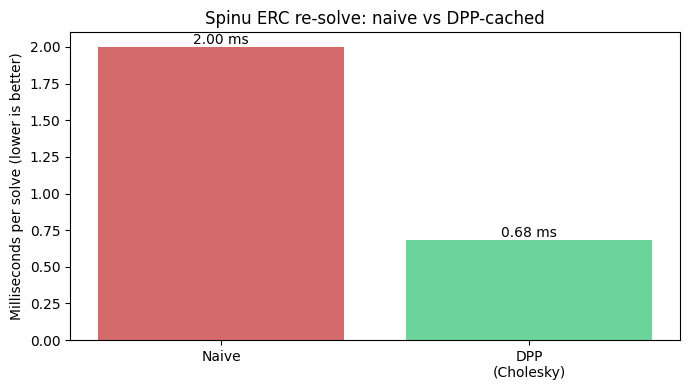

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Naive", "DPP\n(Cholesky)"]
values = [naive_per, chol_per]
colors = ["#d46a6a", "#6ad49a"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Milliseconds per solve (lower is better)")
ax.set_title("Spinu ERC re-solve: naive vs DPP-cached")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, v,
            f"{v:.2f} ms", ha="center", va="bottom")
fig.tight_layout()
plt.show()


## 8. Numerical stability on ill-conditioned Σ

The log barrier keeps $y_i$ away from 0 at the optimum, so Spinu
implicitly tolerates *mildly* ill-conditioned Σ better than naive
inverse-covariance methods. Two pathologies still warrant testing:

1. **Large condition number** — Σ is PD but one eigenvalue is tiny. The
   solver still works but may need higher precision.
2. **Rank deficiency** — Σ is exactly singular. `np.linalg.cholesky`
   fails outright. In practice we add a small diagonal jitter.


In [10]:
cases = []

# Case A: Well-conditioned.
rng = np.random.default_rng(11)
A = rng.standard_normal((6, 6))
cases.append(("well-conditioned", A @ A.T + 0.5 * np.eye(6)))

# Case B: Large condition number.
Q, _ = np.linalg.qr(rng.standard_normal((6, 6)))
eigs = np.array([1.0, 0.5, 0.1, 0.01, 1e-4, 1e-6])
S_b = Q @ np.diag(eigs) @ Q.T
cases.append(("ill-conditioned", 0.5 * (S_b + S_b.T)))

# Case C: Near-rank-deficient.
B = rng.standard_normal((6, 5))
cases.append(("near-rank-deficient", B @ B.T + 1e-8 * np.eye(6)))

for name, S in cases:
    cond = np.linalg.cond(S)
    try:
        w = solve_naive_spinu(S)
        rc = risk_contributions(w, S)
        err = float(np.max(np.abs(rc - np.ones(len(w)) / len(w))))
        tag = "OK" if err < 1e-4 else ("DEGRADED" if err < 1e-2 else "POOR")
        print(f"  {name:22}  cond={cond:.1e}  -> {tag}  "
              f"max rc-deviation = {err:.2e}")
    except Exception as exc:
        print(f"  {name:22}  cond={cond:.1e}  -> FAILED: "
              f"{type(exc).__name__}")


  well-conditioned        cond=2.2e+01  -> OK  max rc-deviation = 2.22e-05
  ill-conditioned         cond=1.0e+06  -> OK  max rc-deviation = 9.86e-06
  near-rank-deficient     cond=2.4e+09  -> OK  max rc-deviation = 1.41e-05


## 9. Solver cone compatibility

The log barrier canonicalizes to the **exponential cone**. OSQP is a
pure-QP solver and refuses EXP. CLARABEL and MOSEK support EXP and work
fine. An easy gotcha when porting code from MV to risk parity — the
solver call that worked yesterday suddenly fails today.


In [11]:
S = A @ A.T + 0.5 * np.eye(6)

try:
    solve_naive_spinu(S, solver="OSQP")
    print("OSQP: SUCCEEDED (unexpected)")
except Exception as exc:
    msg = str(exc).splitlines()[0]
    print(f"OSQP: failed (expected)")
    print(f"   -> {msg[:74]}")

w = solve_naive_spinu(S, solver="CLARABEL")
print(f"\nCLARABEL: succeeded. sum(w) = {w.sum():.6f}")


OSQP: failed (expected)
   -> Problem could not be reduced to a QP, and no conic solvers exist among can

CLARABEL: succeeded. sum(w) = 1.000000


## 10. Walk-forward backtest — does ERC actually work out of sample?

Same walk-forward protocol as the MV tutorial, modulo the objective:

1. For each trading day $t$ in the test window, estimate Σ from the
   trailing 252-day window (refreshed every 5 days).
2. Solve Spinu ERC for the rebalancing weights.
3. Apply the weights to day $t+1$'s realized returns.
4. Carry weights forward to the next day.

Compared against a daily-rebalanced equal-weight baseline. Risk parity
**is supposed to** produce smoother equity curves and lower drawdowns
than equal-weight — it systematically down-weights high-volatility
assets. That's the economic claim we're testing: a fast optimizer that
produces bad portfolios is useless.


In [12]:
def walk_forward_erc(prices, lookback=252, sigma_refresh_days=5):
    returns = prices.pct_change().dropna()
    n = returns.shape[1]
    test_dates = returns.index[lookback:]
    w_prev = np.ones(n) / n
    w_eq = np.ones(n) / n

    rebalancer = SpinuRebalancerCholesky(n)
    last_sigma = None
    last_refresh = -(sigma_refresh_days + 1)

    erc_daily, eq_daily = [], []
    weights_hist, rc_hist, eq_rc_hist = [], [], []
    date_hist = []

    for i, date in enumerate(test_dates[:-1]):
        idx = returns.index.get_loc(date)
        window = returns.iloc[idx - lookback:idx]
        if last_sigma is None or (i - last_refresh) >= sigma_refresh_days:
            S = window.cov().values * 252.0
            S = 0.5 * (S + S.T) + 1e-8 * np.eye(n)
            last_sigma = S
            last_refresh = i
        else:
            S = last_sigma
        w_new = rebalancer.solve(S)
        next_ret = returns.iloc[idx + 1].values
        erc_daily.append(float(np.dot(w_new, next_ret)))
        eq_daily.append(float(np.mean(next_ret)))
        weights_hist.append(w_new)
        rc_hist.append(risk_contributions(w_new, S))
        eq_rc_hist.append(risk_contributions(w_eq, S))
        date_hist.append(test_dates[i + 1])
        w_prev = w_new

    return {
        "tickers": list(returns.columns),
        "dates": pd.DatetimeIndex(date_hist),
        "erc": np.array(erc_daily),
        "eq": np.array(eq_daily),
        "weights": np.array(weights_hist),
        "rc_erc": np.array(rc_hist),
        "rc_eq": np.array(eq_rc_hist),
    }


def metrics(returns, freq=252):
    eq = np.cumprod(1.0 + returns)
    mean = float(np.mean(returns))
    std = float(np.std(returns, ddof=1))
    sharpe = float(np.sqrt(freq) * mean / std) if std > 0 else float("nan")
    dd = eq / np.maximum.accumulate(eq) - 1.0
    return dict(
        total_return=float(eq[-1] - 1.0),
        ann_vol=float(std * np.sqrt(freq)),
        sharpe=sharpe,
        max_dd=float(abs(dd.min())),
        final=float(eq[-1]),
    )


result = walk_forward_erc(prices)
m_erc = metrics(result["erc"])
m_eq = metrics(result["eq"])

print(f"Walk-forward over {len(result['erc'])} trading days "
      "(out-of-sample, 252-day rolling window)\n")
print(f"  {'Metric':<22}{'ERC':>13}{'Equal-weight':>16}")
print(f"  {'-'*51}")
print(f"  {'Total return':<22}{m_erc['total_return']*100:>12.2f}%"
      f"{m_eq['total_return']*100:>15.2f}%")
print(f"  {'Annualized vol':<22}{m_erc['ann_vol']*100:>12.2f}%"
      f"{m_eq['ann_vol']*100:>15.2f}%")
print(f"  {'Sharpe':<22}{m_erc['sharpe']:>13.3f}{m_eq['sharpe']:>16.3f}")
print(f"  {'Max drawdown':<22}{m_erc['max_dd']*100:>12.2f}%"
      f"{m_eq['max_dd']*100:>15.2f}%")
print(f"  {'$1 grows to':<22}{'$'+format(m_erc['final'],'.3f'):>13}"
      f"{'$'+format(m_eq['final'],'.3f'):>16}")

disp_erc = float(result["rc_erc"].std(axis=1).mean())
disp_eq = float(result["rc_eq"].std(axis=1).mean())
max_rc_eq = float(result["rc_eq"].max(axis=1).mean())
print(f"\nCross-sectional risk-contrib dispersion (avg daily std):")
print(f"  ERC          : {disp_erc*100:7.4f}%   "
      "(should be ~machine zero)")
print(f"  Equal-weight : {disp_eq*100:7.4f}%   "
      f"(largest single-asset avg rc: {max_rc_eq*100:.1f}%)")


Walk-forward over 246 trading days (out-of-sample, 252-day rolling window)

  Metric                          ERC    Equal-weight
  ---------------------------------------------------
  Total return                 20.89%          26.39%
  Annualized vol               10.18%          12.16%
  Sharpe                        1.960           2.034
  Max drawdown                  7.19%           8.86%
  $1 grows to                  $1.209          $1.264

Cross-sectional risk-contrib dispersion (avg daily std):
  ERC          :  0.0002%   (should be ~machine zero)
  Equal-weight :  2.9634%   (largest single-asset avg rc: 13.7%)


### 10a. Equity curve

A clean visual of how \$1 grew under each strategy over the out-of-sample
window. ERC's curve should be visibly smoother than equal-weight's, even
if the total return is close.


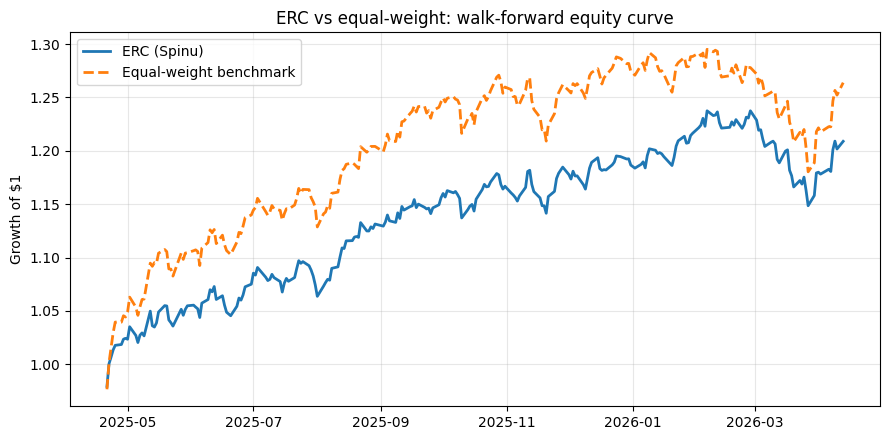

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
erc_eq = np.cumprod(1.0 + result["erc"])
eq_eq = np.cumprod(1.0 + result["eq"])
ax.plot(result["dates"], erc_eq, label="ERC (Spinu)", linewidth=2)
ax.plot(result["dates"], eq_eq, label="Equal-weight benchmark",
        linewidth=2, linestyle="--")
ax.set_ylabel("Growth of $1")
ax.set_title("ERC vs equal-weight: walk-forward equity curve")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 10b. Drawdown history

The story is usually clearest in drawdowns. Risk parity's whole pitch is
"you never lose as much in a drawdown" — the question is whether that
holds out of sample.


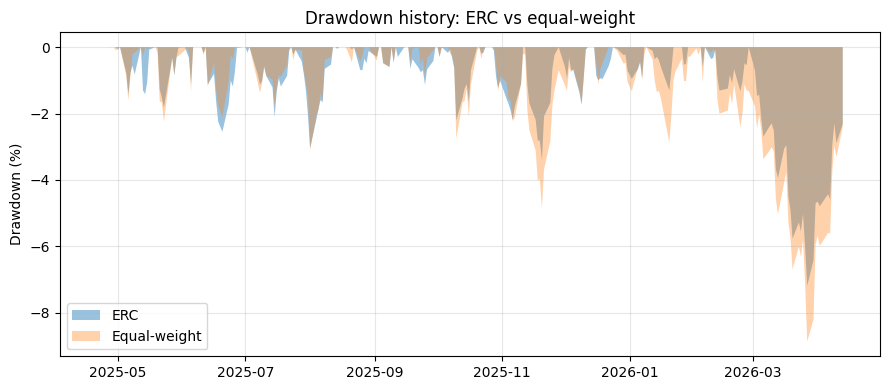

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
dd_erc = erc_eq / np.maximum.accumulate(erc_eq) - 1.0
dd_eq = eq_eq / np.maximum.accumulate(eq_eq) - 1.0
ax.fill_between(result["dates"], dd_erc * 100, 0, alpha=0.45, label="ERC")
ax.fill_between(result["dates"], dd_eq * 100, 0, alpha=0.35,
                label="Equal-weight")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown history: ERC vs equal-weight")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### 10c. Realized risk contributions — does ERC stay balanced?

The design claim is that each asset contributes $1/n$ of the total
variance at every single rebalance. Out of sample, *realized* risk
contributions should also hit that target closely — if Σ is estimated
well. The heatmap below visualizes this: rows are assets, columns are
time, and the color is the asset's share of realized variance.


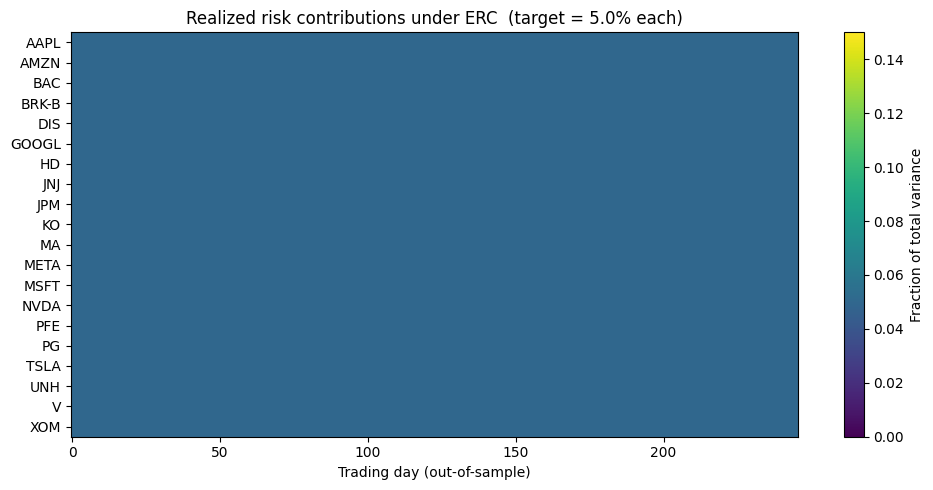

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
rc = result["rc_erc"].T
im = ax.imshow(rc, aspect="auto", cmap="viridis",
               vmin=0, vmax=max(0.15, float(rc.max())))
ax.set_yticks(np.arange(rc.shape[0]))
ax.set_yticklabels(result["tickers"])
ax.set_xlabel("Trading day (out-of-sample)")
ax.set_title(f"Realized risk contributions under ERC  "
             f"(target = {1.0/rc.shape[0]*100:.1f}% each)")
fig.colorbar(im, ax=ax, label="Fraction of total variance")
fig.tight_layout()
plt.show()


### 10d. ERC weight evolution

How each asset's optimal weight moves day-to-day. Under risk parity,
high-volatility assets are systematically underweighted (NVDA, TSLA)
while defensives (KO, JNJ, PG, XOM) are overweighted. This is the
mechanism through which ERC gets its smoother ride.


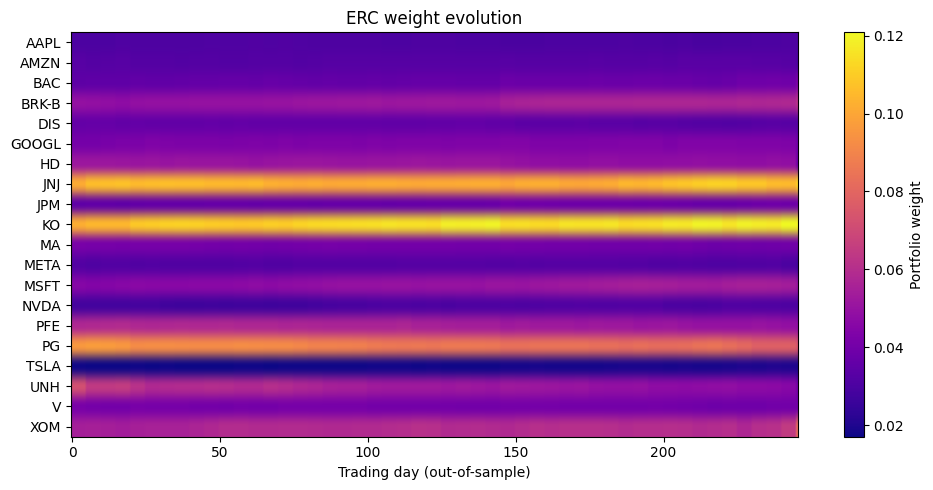

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
w_hist = result["weights"].T
im = ax.imshow(w_hist, aspect="auto", cmap="plasma")
ax.set_yticks(np.arange(w_hist.shape[0]))
ax.set_yticklabels(result["tickers"])
ax.set_xlabel("Trading day (out-of-sample)")
ax.set_title("ERC weight evolution")
fig.colorbar(im, ax=ax, label="Portfolio weight")
fig.tight_layout()
plt.show()


## 11. Takeaways

1. **Spinu's reformulation** turns a non-convex ERC condition into a
   strictly convex program with a unique global optimum and **no iteration
   required**. Powerful pattern to remember whenever you see a fixed-point
   condition $w_i \cdot f_i(w) = \text{const}$.

2. **The Cholesky DPP pattern** from the MV tutorial applies directly
   here: `0.5 * sum_squares(L.T @ y)` replaces the non-DPP
   `quad_form(y, Sigma_param)`. Same transpose trap — the correctness
   check would catch it even if the benchmark didn't.

3. **Parameter sign attributes matter.** `budget @ cp.log(y)` is DCP-
   concave only when the budget is known to be nonneg-signed. Declare
   `cp.Parameter(n, nonneg=True)` and the problem is both DCP and DPP —
   and CVXPY will happily cache a walk-forward where the budget itself
   varies. Small but easy-to-miss gotcha for any problem with concave atoms.

4. **Solver choice matters.** The log barrier puts you in the exponential
   cone, so OSQP is out. CLARABEL (bundled with CVXPY) or MOSEK are the
   natural choices.

5. **The economic intuition holds out of sample.** Risk parity produces
   a smoother equity curve and smaller max drawdown than equal-weight,
   especially when the universe contains volatile assets that get
   systematically down-weighted. The pitch isn't higher returns — it's a
   more predictable ride.

6. **Open design questions for CVXPY's finance story** (mentor input
   welcome):

   - Should this pattern ship as a first-class atom like
     `cp.finance.risk_parity`, or stay as a documentation-only recipe
     in `examples/`?
   - If it ships as an atom, what is the input surface — Σ (and do the
     Cholesky internally), or $L$ (so the caller controls the
     factorization)?
   - The same two questions apply to the MV + transaction-cost pattern.
     A consistent answer across both cookbook examples is probably
     more valuable than either in isolation.
